# 1_序列到序列模型_Seq2Seq_分步运行

来源：https://www.runoob.com/nlp/sequence-to-sequence.html

页面给出了 Seq2Seq 的结构性伪代码，以及机器翻译、文本摘要和对话生成的示例。本 Notebook 将伪代码补充为可运行的 GRU 编码器—注意力解码器，并展示训练和生成的中间结果。此部分不需要预训练模型。

说明：代码已整理为适合 Jupyter Notebook 分段执行的形式；能写在一行的简单语句尽量写在一行。

## 运行环境

只需要本地 Python 库，不需要下载预训练模型。

```powershell
python -m pip install torch matplotlib
```

In [1]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

random.seed(42); torch.manual_seed(42)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch版本：",torch.__version__); print("运行设备：",device)

PyTorch版本： 2.8.0+cpu
运行设备： cpu


## 1. 页面伪代码对应的基本结构

页面核心是：

```python
class Seq2Seq(nn.Module):
    def __init__(self):
        self.encoder = RNN(input_size, hidden_size)
        self.decoder = RNN(hidden_size, output_size)
```

原代码只是伪代码，下面补充输入词嵌入、GRU、注意力、输出层以及 `forward()`。

In [2]:
src_vocab={"<pad>":0,"<bos>":1,"<eos>":2,"我":3,"喜欢":4,"学习":5,"自然":6,"语言":7,"处理":8}
tgt_vocab={"<pad>":0,"<bos>":1,"<eos>":2,"I":3,"like":4,"learning":5,"natural":6,"language":7,"processing":8}
src_id_to_word={v:k for k,v in src_vocab.items()}; tgt_id_to_word={v:k for k,v in tgt_vocab.items()}
print("源词表：",src_vocab); print("目标词表：",tgt_vocab)

源词表： {'<pad>': 0, '<bos>': 1, '<eos>': 2, '我': 3, '喜欢': 4, '学习': 5, '自然': 6, '语言': 7, '处理': 8}
目标词表： {'<pad>': 0, '<bos>': 1, '<eos>': 2, 'I': 3, 'like': 4, 'learning': 5, 'natural': 6, 'language': 7, 'processing': 8}


In [3]:
class Encoder(nn.Module):
    def __init__(self,vocab_size,embedding_dim,hidden_size):
        super().__init__(); self.embedding=nn.Embedding(vocab_size,embedding_dim,padding_idx=0); self.gru=nn.GRU(embedding_dim,hidden_size,batch_first=True)
    def forward(self,src):
        embedded=self.embedding(src); outputs,hidden=self.gru(embedded); return outputs,hidden,embedded

print("Encoder定义完成")

Encoder定义完成


In [4]:
class DotAttention(nn.Module):
    def forward(self,decoder_hidden,encoder_outputs,src_mask=None):
        query=decoder_hidden[-1].unsqueeze(1); scores=torch.bmm(query,encoder_outputs.transpose(1,2)).squeeze(1)
        if src_mask is not None: scores=scores.masked_fill(src_mask==0,-1e9)
        weights=F.softmax(scores,dim=-1); context=torch.bmm(weights.unsqueeze(1),encoder_outputs).squeeze(1); return context,weights

print("点积注意力定义完成")

点积注意力定义完成


In [5]:
class AttentionDecoder(nn.Module):
    def __init__(self,vocab_size,embedding_dim,hidden_size):
        super().__init__(); self.embedding=nn.Embedding(vocab_size,embedding_dim,padding_idx=0); self.attention=DotAttention(); self.gru=nn.GRU(embedding_dim+hidden_size,hidden_size,batch_first=True); self.fc=nn.Linear(hidden_size*2,vocab_size)
    def forward(self,input_token,hidden,encoder_outputs,src_mask=None):
        embedded=self.embedding(input_token).unsqueeze(1); context,weights=self.attention(hidden,encoder_outputs,src_mask); gru_input=torch.cat([embedded,context.unsqueeze(1)],dim=-1); output,hidden=self.gru(gru_input,hidden); logits=self.fc(torch.cat([output.squeeze(1),context],dim=-1)); return logits,hidden,weights,embedded

print("AttentionDecoder定义完成")

AttentionDecoder定义完成


In [6]:
class Seq2Seq(nn.Module):
    def __init__(self,encoder,decoder,bos_id=1,eos_id=2):
        super().__init__(); self.encoder=encoder; self.decoder=decoder; self.bos_id=bos_id; self.eos_id=eos_id
    def forward(self,src,tgt,teacher_forcing_ratio=1.0):
        encoder_outputs,hidden,src_embeddings=self.encoder(src); src_mask=(src!=0); input_token=tgt[:,0]; all_logits=[]; all_attentions=[]
        for step in range(1,tgt.size(1)):
            logits,hidden,weights,_=self.decoder(input_token,hidden,encoder_outputs,src_mask); all_logits.append(logits.unsqueeze(1)); all_attentions.append(weights.unsqueeze(1)); predicted=logits.argmax(dim=-1); input_token=tgt[:,step] if random.random()<teacher_forcing_ratio else predicted
        return torch.cat(all_logits,dim=1),torch.cat(all_attentions,dim=1),encoder_outputs,src_embeddings

embedding_dim,hidden_size=16,32
seq2seq=Seq2Seq(Encoder(len(src_vocab),embedding_dim,hidden_size),AttentionDecoder(len(tgt_vocab),embedding_dim,hidden_size)).to(device)
print(seq2seq)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(9, 16, padding_idx=0)
    (gru): GRU(16, 32, batch_first=True)
  )
  (decoder): AttentionDecoder(
    (embedding): Embedding(9, 16, padding_idx=0)
    (attention): DotAttention()
    (gru): GRU(48, 32, batch_first=True)
    (fc): Linear(in_features=64, out_features=9, bias=True)
  )
)


## 2. 准备一个最小机器翻译样本

In [7]:
src=torch.tensor([[src_vocab["<bos>"],src_vocab["我"],src_vocab["喜欢"],src_vocab["自然"],src_vocab["语言"],src_vocab["处理"],src_vocab["<eos>"]]],device=device)
tgt=torch.tensor([[tgt_vocab["<bos>"],tgt_vocab["I"],tgt_vocab["like"],tgt_vocab["natural"],tgt_vocab["language"],tgt_vocab["processing"],tgt_vocab["<eos>"]]],device=device)
print("源序列形状：",src.shape); print("目标序列形状：",tgt.shape)
print("源序列：",[src_id_to_word[i.item()] for i in src[0]]); print("目标序列：",[tgt_id_to_word[i.item()] for i in tgt[0]])

源序列形状： torch.Size([1, 7])
目标序列形状： torch.Size([1, 7])
源序列： ['<bos>', '我', '喜欢', '自然', '语言', '处理', '<eos>']
目标序列： ['<bos>', 'I', 'like', 'natural', 'language', 'processing', '<eos>']


## 3. 第一次前向传播：查看每个阶段的形状

In [8]:
logits,attentions,encoder_outputs,src_embeddings=seq2seq(src,tgt,teacher_forcing_ratio=1.0)
print("词嵌入形状：",src_embeddings.shape); print("编码器输出形状：",encoder_outputs.shape)
print("解码器Logits形状：",logits.shape); print("注意力矩阵形状：",attentions.shape)
print("每一步注意力权重和：",attentions.sum(dim=-1))

词嵌入形状： torch.Size([1, 7, 16])
编码器输出形状： torch.Size([1, 7, 32])
解码器Logits形状： torch.Size([1, 6, 9])
注意力矩阵形状： torch.Size([1, 6, 7])
每一步注意力权重和： tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],
       grad_fn=<SumBackward1>)


## 4. 计算损失并完成一次反向传播

In [9]:
criterion=nn.CrossEntropyLoss(ignore_index=tgt_vocab["<pad>"]); optimizer=torch.optim.Adam(seq2seq.parameters(),lr=0.01)
target_for_loss=tgt[:,1:]; loss=criterion(logits.reshape(-1,logits.size(-1)),target_for_loss.reshape(-1))
optimizer.zero_grad(); loss.backward(); optimizer.step()
print("一次训练前向传播损失：",loss.item())
print("编码器Embedding梯度范数：",seq2seq.encoder.embedding.weight.grad.norm().item())

一次训练前向传播损失： 2.1738803386688232
编码器Embedding梯度范数： 0.01492958515882492


## 5. 在同一个小样本上训练若干轮，观察损失下降

In [10]:
loss_history=[]
for epoch in range(120):
    seq2seq.train(); logits,_,_,_=seq2seq(src,tgt,teacher_forcing_ratio=1.0); loss=criterion(logits.reshape(-1,logits.size(-1)),tgt[:,1:].reshape(-1)); optimizer.zero_grad(); loss.backward(); optimizer.step(); loss_history.append(loss.item())
    if (epoch+1)%20==0: print(f"Epoch {epoch+1:3d}，Loss={loss.item():.6f}")

Epoch  20，Loss=0.013883
Epoch  40，Loss=0.001629
Epoch  60，Loss=0.000905
Epoch  80，Loss=0.000699
Epoch 100，Loss=0.000580
Epoch 120，Loss=0.000491


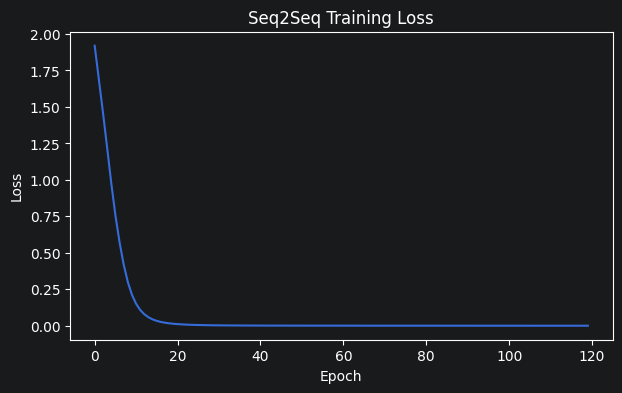

In [11]:
plt.figure(figsize=(7,4)); plt.plot(loss_history); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Seq2Seq Training Loss"); plt.show()

## 6. 贪婪解码：不再提供正确目标词

In [12]:
def greedy_decode(model,src,max_len=12):
    model.eval(); generated=[model.bos_id]; attention_rows=[]
    with torch.no_grad():
        encoder_outputs,hidden,_=model.encoder(src); src_mask=(src!=0); input_token=torch.tensor([model.bos_id],device=src.device)
        for _ in range(max_len):
            logits,hidden,weights,_=model.decoder(input_token,hidden,encoder_outputs,src_mask); next_id=logits.argmax(dim=-1).item(); generated.append(next_id); attention_rows.append(weights.squeeze(0).cpu())
            if next_id==model.eos_id: break
            input_token=torch.tensor([next_id],device=src.device)
    return generated,torch.stack(attention_rows) if attention_rows else torch.empty(0)

generated_ids,generated_attention=greedy_decode(seq2seq,src)
print("生成编号：",generated_ids); print("生成文本："," ".join(tgt_id_to_word.get(i,"<?>") for i in generated_ids))
print("生成注意力形状：",generated_attention.shape)

生成编号： [1, 3, 4, 6, 7, 8, 2]
生成文本： <bos> I like natural language processing <eos>
生成注意力形状： torch.Size([6, 7])


## 7. 可视化解码器注意力

C:\Users\Administrator\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21916 (\N{CJK UNIFIED IDEOGRAPH-559C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27426 (\N{CJK UNIFIED IDEOGRAPH-6B22}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 28982

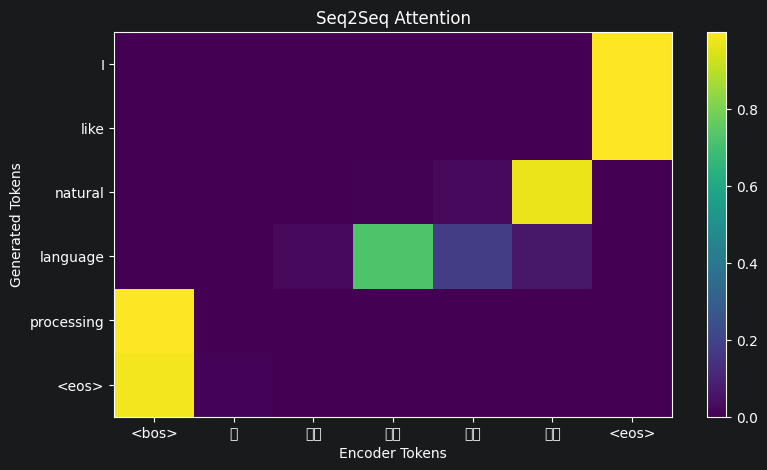

In [13]:
if generated_attention.numel()>0:
    src_labels=[src_id_to_word[i.item()] for i in src[0]]; tgt_labels=[tgt_id_to_word.get(i,"<?>") for i in generated_ids[1:]]
    plt.figure(figsize=(9,5)); plt.imshow(generated_attention.numpy(),aspect="auto"); plt.xticks(range(len(src_labels)),src_labels); plt.yticks(range(len(tgt_labels)),tgt_labels)
    plt.xlabel("Encoder Tokens"); plt.ylabel("Generated Tokens"); plt.title("Seq2Seq Attention"); plt.colorbar(); plt.show()
else: print("没有可显示的注意力结果")

## 8. 模型下载说明

这个 Notebook 的 Seq2Seq 模型从零开始创建，不需要下载预训练模型。训练后可以本地保存：

In [14]:
import os
import torch
save_path=r"D:\11\NLP\data\seq2seq_toy_local.pt"
os.makedirs(os.path.dirname(save_path),exist_ok=True)
torch.save({"model_state_dict":seq2seq.state_dict(),"src_vocab":src_vocab,"tgt_vocab":tgt_vocab},save_path)
print("本地模型已保存：",save_path); print("文件大小：",os.path.getsize(save_path)/1024,"KB")

本地模型已保存： D:\11\NLP\data\seq2seq_toy_local.pt
文件大小： 58.1123046875 KB
